In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/Users/powerbai/Desktop/Power Bai/Data Analyst Bootcamp/Portfolio Projects/Credit Risk & Portfolio Performance Dashboard/consumer_credit_trend_forecasting_for_python.csv')
print(df.head())
print(df.info())

  issue_month  loan_count  bad_count  bad_outcome_rate  avg_int_rate  \
0  2007-10-01         105         34          0.323810       12.4385   
1  2007-11-01         112         34          0.303571       11.9623   
2  2007-12-01         172         47          0.273256       11.8105   
3  2008-01-01         305         84          0.275410       11.7204   
4  2008-02-01         306         61          0.199346       12.1959   

   avg_fico   avg_lti  share_60m  share_low_grade  low_volume_flag  
0    685.86  0.177483        0.0         0.552381                0  
1    685.39  0.194702        0.0         0.500000                0  
2    690.81  0.207158        0.0         0.476744                0  
3    696.20  0.186176        0.0         0.406557                0  
4    698.03  0.182945        0.0         0.431373                0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
-

In [5]:
df["issue_month"] = pd.to_datetime(df["issue_month"])
df = df.sort_values("issue_month").reset_index(drop = True)
df = df.set_index("issue_month")
df = df.asfreq("MS")

print(df.head())
print(df.index.min(), df.index.max(), len(df))

             loan_count  bad_count  bad_outcome_rate  avg_int_rate  avg_fico  \
issue_month                                                                    
2007-10-01          105         34          0.323810       12.4385    685.86   
2007-11-01          112         34          0.303571       11.9623    685.39   
2007-12-01          172         47          0.273256       11.8105    690.81   
2008-01-01          305         84          0.275410       11.7204    696.20   
2008-02-01          306         61          0.199346       12.1959    698.03   

              avg_lti  share_60m  share_low_grade  low_volume_flag  
issue_month                                                         
2007-10-01   0.177483        0.0         0.552381                0  
2007-11-01   0.194702        0.0         0.500000                0  
2007-12-01   0.207158        0.0         0.476744                0  
2008-01-01   0.186176        0.0         0.406557                0  
2008-02-01   0.182945    

In [6]:
# bad outcome rate

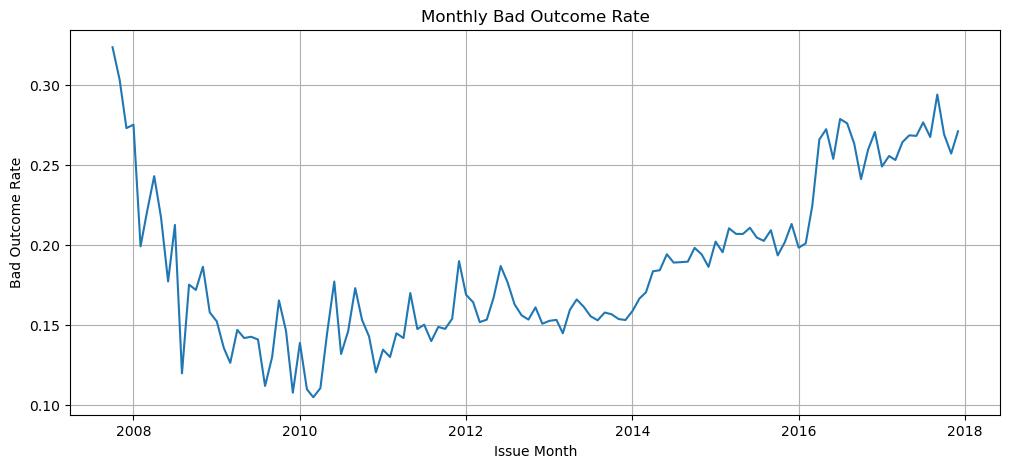

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["bad_outcome_rate"])
plt.title("Monthly Bad Outcome Rate")
plt.xlabel("Issue Month")
plt.ylabel("Bad Outcome Rate")
plt.grid(True)
plt.show()

In [8]:
# loan count

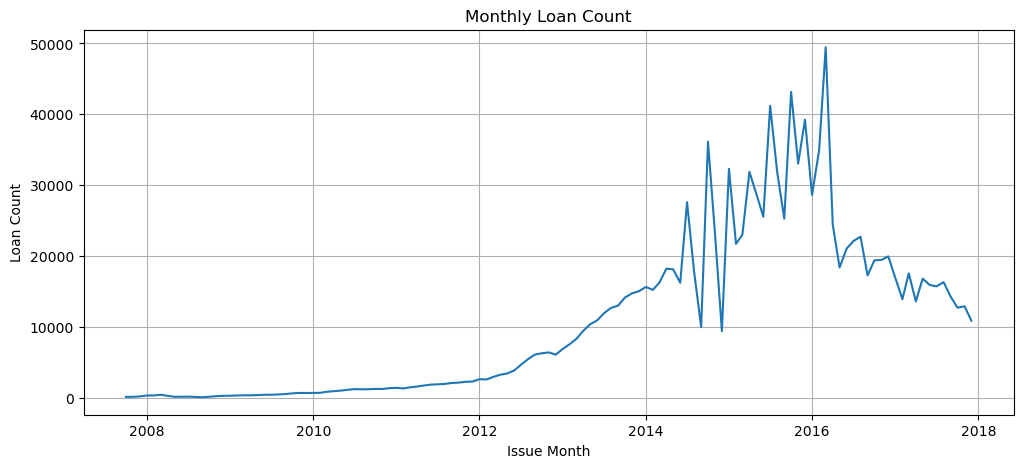

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["loan_count"])
plt.title("Monthly Loan Count")
plt.xlabel("Issue Month")
plt.ylabel("Loan Count")
plt.grid(True)
plt.show()

In [10]:
# portfolio mix

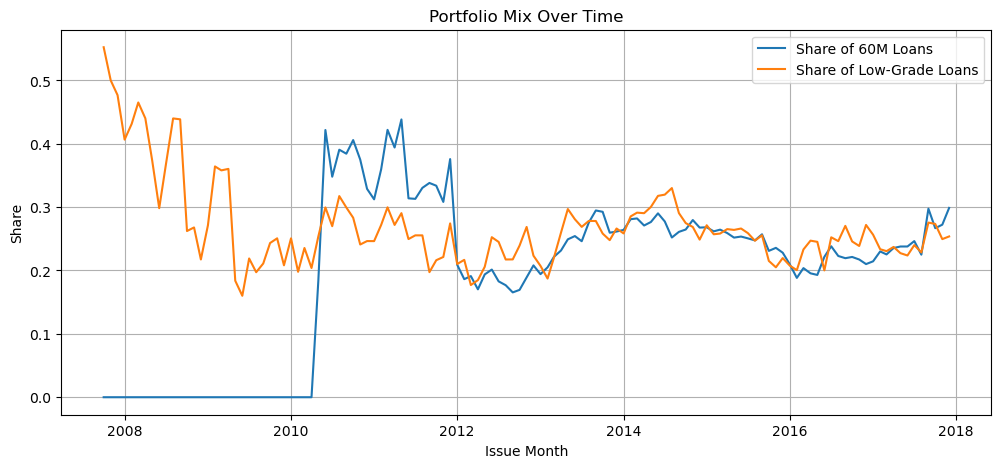

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["share_60m"], label="Share of 60M Loans")
plt.plot(df.index, df["share_low_grade"], label="Share of Low-Grade Loans")
plt.title("Portfolio Mix Over Time")
plt.xlabel("Issue Month")
plt.ylabel("Share")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# AVG interest rate/FICO/LTI over time

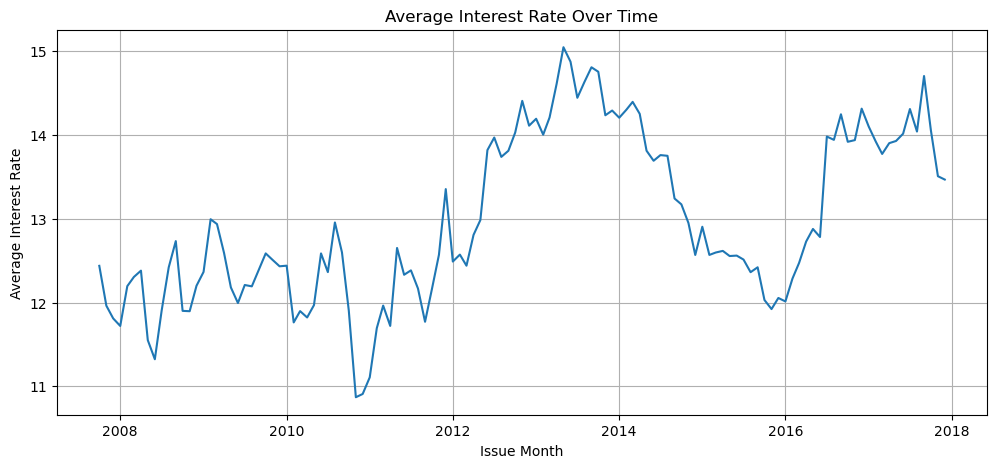

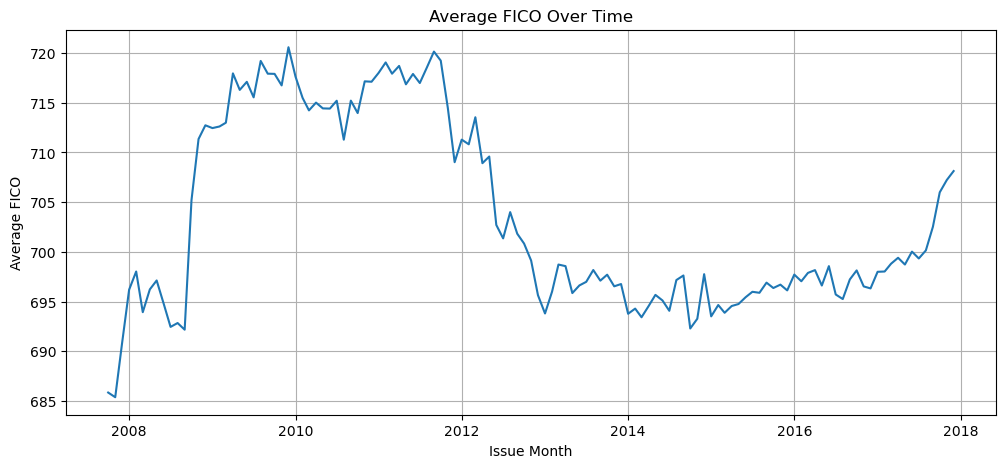

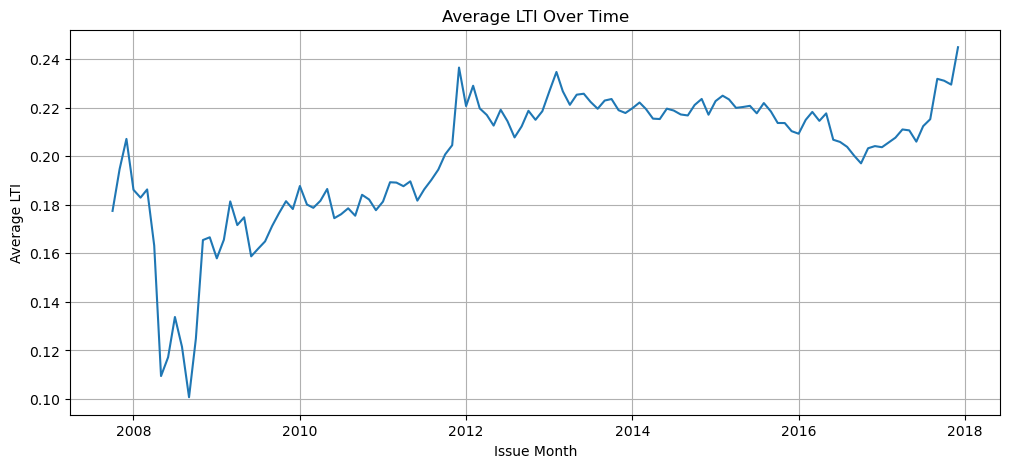

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["avg_int_rate"])
plt.title("Average Interest Rate Over Time")
plt.xlabel("Issue Month")
plt.ylabel("Average Interest Rate")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["avg_fico"])
plt.title("Average FICO Over Time")
plt.xlabel("Issue Month")
plt.ylabel("Average FICO")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["avg_lti"])
plt.title("Average LTI Over Time")
plt.xlabel("Issue Month")
plt.ylabel("Average LTI")
plt.grid(True)
plt.show()

In [14]:
# Rolling mean

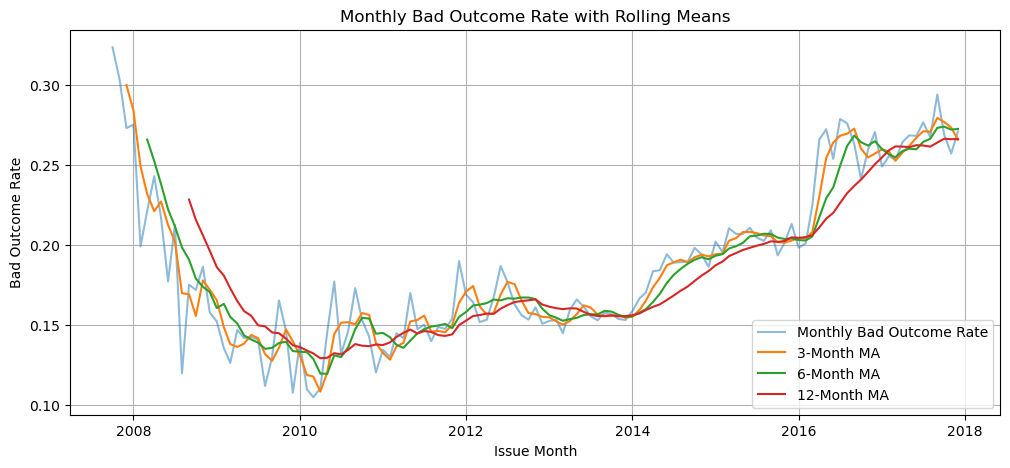

In [15]:
df["bad_rate_3ma"] = df["bad_outcome_rate"].rolling(window=3).mean()
df["bad_rate_6ma"] = df["bad_outcome_rate"].rolling(window=6).mean()
df["bad_rate_12ma"] = df["bad_outcome_rate"].rolling(window=12).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["bad_outcome_rate"], label="Monthly Bad Outcome Rate", alpha=0.5)
plt.plot(df.index, df["bad_rate_3ma"], label="3-Month MA")
plt.plot(df.index, df["bad_rate_6ma"], label="6-Month MA")
plt.plot(df.index, df["bad_rate_12ma"], label="12-Month MA")
plt.title("Monthly Bad Outcome Rate with Rolling Means")
plt.xlabel("Issue Month")
plt.ylabel("Bad Outcome Rate")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# basic info

In [17]:
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

         loan_count     bad_count  bad_outcome_rate  avg_int_rate    avg_fico  \
count    123.000000    123.000000        123.000000    123.000000  123.000000   
mean   10616.365854   2233.243902          0.187520     12.974549  703.401707   
std    11515.928916   2536.482725          0.050139      0.994285    9.534300   
min       57.000000     10.000000          0.105072     10.869500  685.390000   
25%      950.500000    122.500000          0.151515     12.205150  696.070000   
50%     6263.000000    962.000000          0.173255     12.599400  698.570000   
75%    17068.500000   4257.000000          0.211865     13.934600  713.750000   
max    49466.000000  11123.000000          0.323810     15.049000  720.580000   

          avg_lti   share_60m  share_low_grade  low_volume_flag  bad_rate_3ma  \
count  123.000000  123.000000       123.000000       123.000000    121.000000   
mean     0.199423    0.196052         0.268903         0.008130      0.185796   
std      0.027423    0.1266

In [18]:
# target summary

In [19]:
y = df["bad_outcome_rate"].asfreq("MS")

print("Target summary:")
print(y.describe())

Target summary:
count    123.000000
mean       0.187520
std        0.050139
min        0.105072
25%        0.151515
50%        0.173255
75%        0.211865
max        0.323810
Name: bad_outcome_rate, dtype: float64


In [20]:
# divide train/test

In [21]:
y = df["bad_outcome_rate"].asfreq("MS")

split_idx = int(len(y) * 0.8)
train = y.iloc[:split_idx]
test = y.iloc[split_idx:]

print("Train start:", train.index.min(), "Train end:", train.index.max(), "Train size:", len(train))
print("Test start:", test.index.min(), "Test end:", test.index.max(), "Test size:", len(test))

Train start: 2007-10-01 00:00:00 Train end: 2015-11-01 00:00:00 Train size: 98
Test start: 2015-12-01 00:00:00 Test end: 2017-12-01 00:00:00 Test size: 25


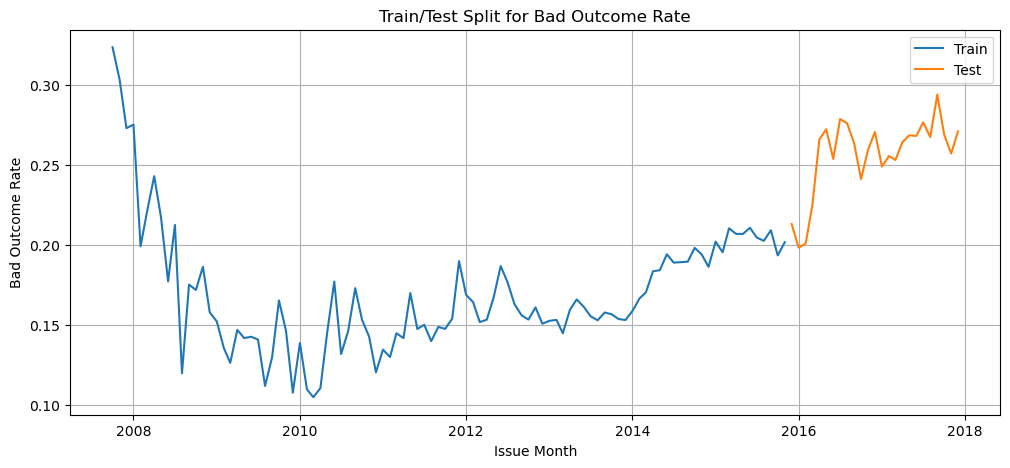

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.title("Train/Test Split for Bad Outcome Rate")
plt.xlabel("Issue Month")
plt.ylabel("Bad Outcome Rate")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Naive Forecast

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

naive_pred = np.repeat(train.iloc[-1], len(test))

naive_mae = mean_absolute_error(test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(test, naive_pred))

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)

Naive MAE: 0.05514163999999999
Naive RMSE: 0.059633438915091916


In [25]:
# Rolling mean forecast

In [26]:
rolling_mean_value = train.iloc[-3:].mean()
rolling_mean_pred = np.repeat(rolling_mean_value, len(test))

rolling_mae = mean_absolute_error(test, rolling_mean_pred)
rolling_rmse = np.sqrt(mean_squared_error(test, rolling_mean_pred))

print("Rolling Mean MAE:", rolling_mae)
print("Rolling Mean RMSE:", rolling_rmse)

Rolling Mean MAE: 0.055328120000000015
Rolling Mean RMSE: 0.05983756407374887


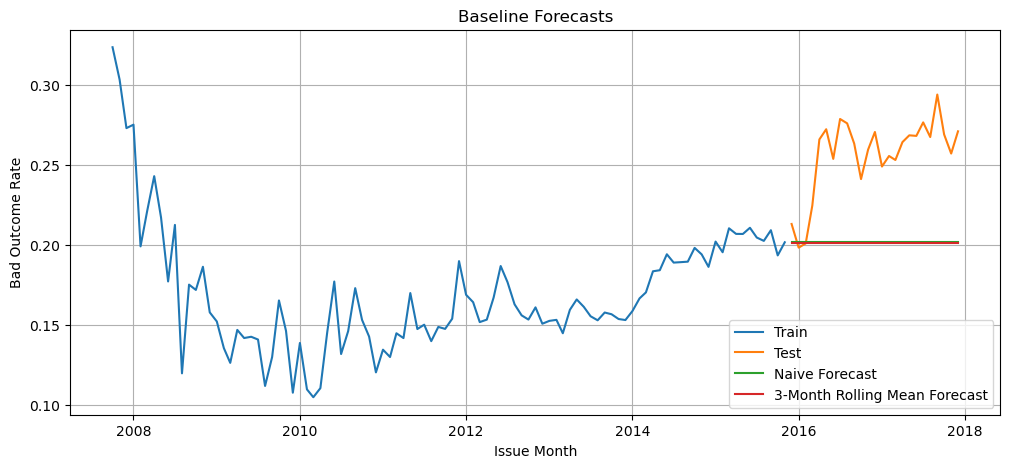

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, naive_pred, label="Naive Forecast")
plt.plot(test.index, rolling_mean_pred, label="3-Month Rolling Mean Forecast")
plt.title("Baseline Forecasts")
plt.xlabel("Issue Month")
plt.ylabel("Bad Outcome Rate")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Forecasting

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [30]:
y = df["bad_outcome_rate"]

split_idx = int(len(y) * 0.8)
train = y.iloc[:split_idx]
test = y.iloc[split_idx:]

In [31]:
results = []

naive_pred = np.repeat(train.iloc[-1], len(test))
naive_mae = mean_absolute_error(test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(test, naive_pred))
results.append(["Naive", naive_mae, naive_rmse])

rolling_mean_value = train.iloc[-3:].mean()
rolling_mean_pred = np.repeat(rolling_mean_value, len(test))
rolling_mae = mean_absolute_error(test, rolling_mean_pred)
rolling_rmse = np.sqrt(mean_squared_error(test, rolling_mean_pred))
results.append(["Rolling Mean (3M)", rolling_mae, rolling_rmse])

print(results)

[['Naive', 0.05514163999999999, np.float64(0.059633438915091916)], ['Rolling Mean (3M)', 0.055328120000000015, np.float64(0.05983756407374887)]]


In [32]:
# Check ACF&PACF

<Figure size 1200x500 with 0 Axes>

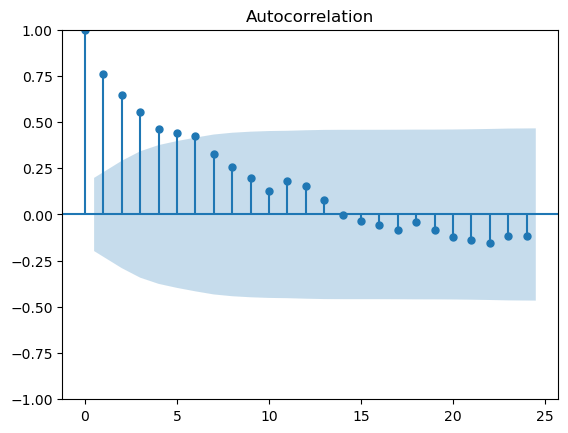

<Figure size 1200x500 with 0 Axes>

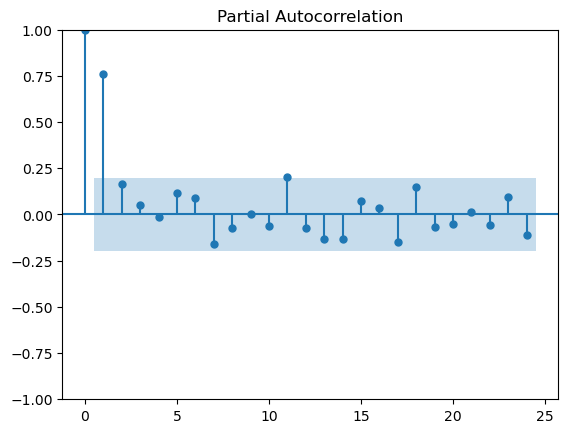

In [33]:
plt.figure(figsize=(12, 5))
plot_acf(train, lags=24)
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(train, lags=24, method="ywm")
plt.show()

In [34]:
# Holt Linear

In [35]:
holt_model = Holt(train, initialization_method="estimated").fit()
holt_pred = holt_model.forecast(len(test))

holt_mae = mean_absolute_error(test, holt_pred)
holt_rmse = np.sqrt(mean_squared_error(test, holt_pred))

results.append(["Holt Linear Trend", holt_mae, holt_rmse])

print("Holt MAE:", holt_mae)
print("Holt RMSE:", holt_rmse)

Holt MAE: 0.058877054353741035
Holt RMSE: 0.06374586808134364


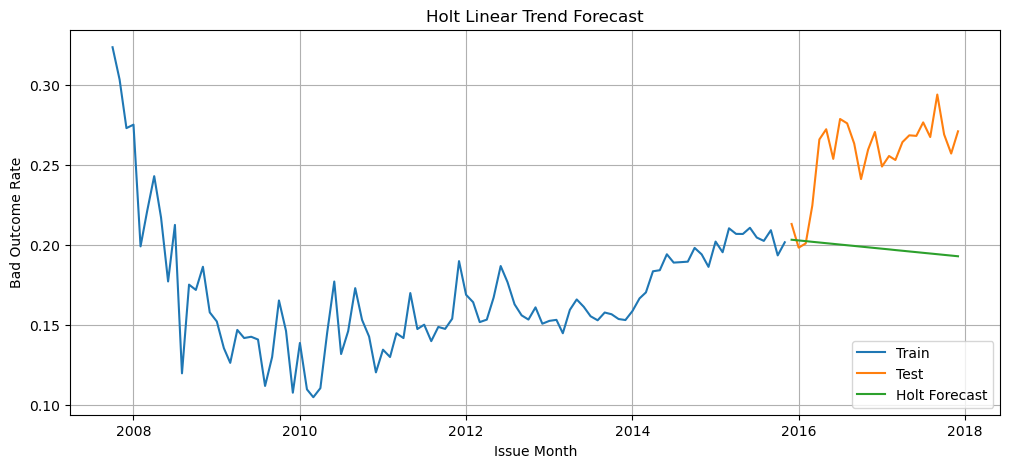

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, holt_pred, label="Holt Forecast")
plt.title("Holt Linear Trend Forecast")
plt.xlabel("Issue Month")
plt.ylabel("Bad Outcome Rate")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
#ARIMA

In [38]:
arima_candidates = [(1,1,0), (0,1,1), (1,1,1), (2,1,1)]
arima_outputs = []

for order in arima_candidates:
    try:
        model = ARIMA(train, order=order)
        fitted = model.fit()
        pred = fitted.forecast(steps=len(test))

        mae = mean_absolute_error(test, pred)
        rmse = np.sqrt(mean_squared_error(test, pred))

        arima_outputs.append((order, mae, rmse, pred, fitted.aic))
        print(f"ARIMA{order} | MAE={mae:.6f} | RMSE={rmse:.6f} | AIC={fitted.aic:.2f}")
    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

ARIMA(1, 1, 0) | MAE=0.057044 | RMSE=0.061563 | AIC=-478.48
ARIMA(0, 1, 1) | MAE=0.056126 | RMSE=0.060677 | AIC=-479.80
ARIMA(1, 1, 1) | MAE=0.056305 | RMSE=0.060853 | AIC=-477.85
ARIMA(2, 1, 1) | MAE=0.056302 | RMSE=0.060854 | AIC=-475.86


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [39]:
best_arima = min(arima_outputs, key=lambda x: x[2])  # 按 RMSE 最小选
best_order, best_mae, best_rmse, best_pred, best_aic = best_arima

results.append([f"ARIMA{best_order}", best_mae, best_rmse])

print("Best ARIMA order:", best_order)
print("Best ARIMA MAE:", best_mae)
print("Best ARIMA RMSE:", best_rmse)
print("Best ARIMA AIC:", best_aic)

Best ARIMA order: (0, 1, 1)
Best ARIMA MAE: 0.056126215278504116
Best ARIMA RMSE: 0.060676823297845545
Best ARIMA AIC: -479.79869935555826


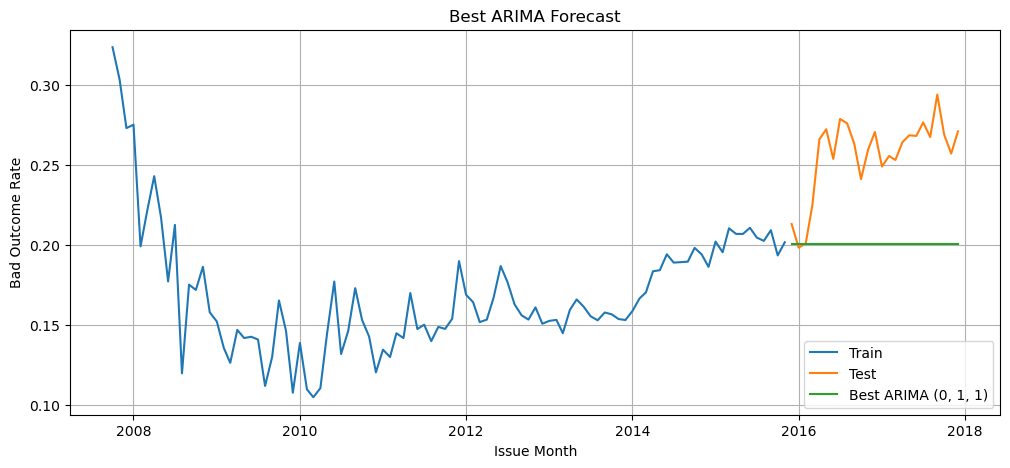

In [40]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, best_pred, label=f"Best ARIMA {best_order}")
plt.title("Best ARIMA Forecast")
plt.xlabel("Issue Month")
plt.ylabel("Bad Outcome Rate")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
# together

In [42]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE"])
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

print(results_df)

               Model       MAE      RMSE
0              Naive  0.055142  0.059633
1  Rolling Mean (3M)  0.055328  0.059838
2     ARIMA(0, 1, 1)  0.056126  0.060677
3  Holt Linear Trend  0.058877  0.063746


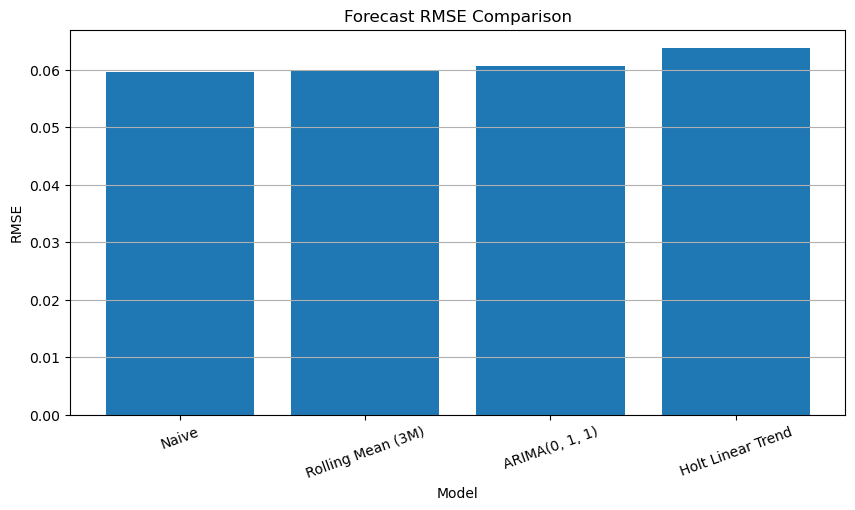

In [43]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Forecast RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

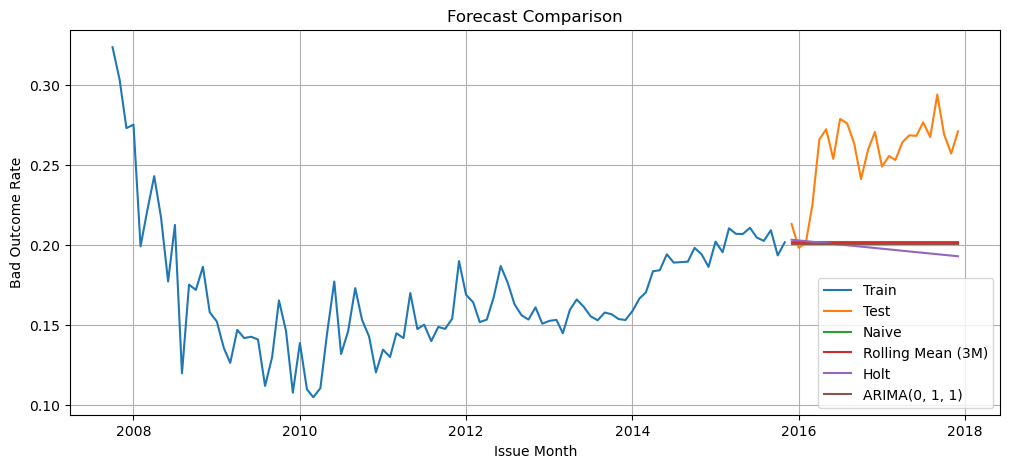

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, naive_pred, label="Naive")
plt.plot(test.index, rolling_mean_pred, label="Rolling Mean (3M)")
plt.plot(test.index, holt_pred, label="Holt")
plt.plot(test.index, best_pred, label=f"ARIMA{best_order}")
plt.title("Forecast Comparison")
plt.xlabel("Issue Month")
plt.ylabel("Bad Outcome Rate")
plt.legend()
plt.grid(True)
plt.show()